In [42]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii
from astropy import units as u
from astropy.table import Table, vstack, hstack
import line_ratios as lr
from scipy.optimize import curve_fit

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../')
# import src.ifu_tools.line_ratios as lr

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()

True

In [2]:
rest_lambdas = {
# --- Primary [OIII] and [OII] ---
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'oii3729':  3728.82,

# --- Hydrogen Balmer Series ---
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,

# --- Key Diagnostic Lines ---
'oiii4363': 4363.21,
'neiii':    3868.75,

# --- Low-Ionization Lines ---
'nii6583':  6583.45,
'nii6548':  6548.05,
'sii6716':  6716.44,
'sii6731':  6730.82,

# --- Helium Lines ---
'heii4686': 4685.68,
'hei5876':  5875.62,
}
balmer_lambda = {
# 'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,
}
lambda_keys = {
# --- Primary [OIII] and [OII] ---
'oiii5007': r'[OIII] $\lambda$5007',
'oiii4959': r'[OIII] $\lambda$4959',
'oii3726':  r'[OII] $\lambda$3726',
'oii3729':  r'[OII] $\lambda$3729',

# --- Hydrogen Balmer Series ---
'halpha':   r'H$\alpha$',
'hbeta':    r'H$\beta$',
'hgamma':   r'H$\gamma$',
'hdelta':   r'H$\delta$',
'hepsilon': r'H$\epsilon$',
'hzeta':    r'H$\zeta$',
'heta':     r'H$\eta$',

# --- Key Diagnostic Lines ---
'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
'neiii':    r'[NeIII] $\lambda$3869',

# --- Low-Ionization Lines ---
'nii6583':  r'[NII] $\lambda$6583',
'nii6548':  r'[NII] $\lambda$6548',
'sii6716':  r'[SII] $\lambda$6716',
'sii6731':  r'[SII] $\lambda$6731',

# --- Helium Lines (not forbidden) ---
'heii4686': r'HeII $\lambda$4686',
'hei5876':  r'HeI $\lambda$5876',
}

In [3]:
test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']

In [41]:
def linear(x, *params):
    return params[0]*x+params[1]

In [ ]:
tab

True

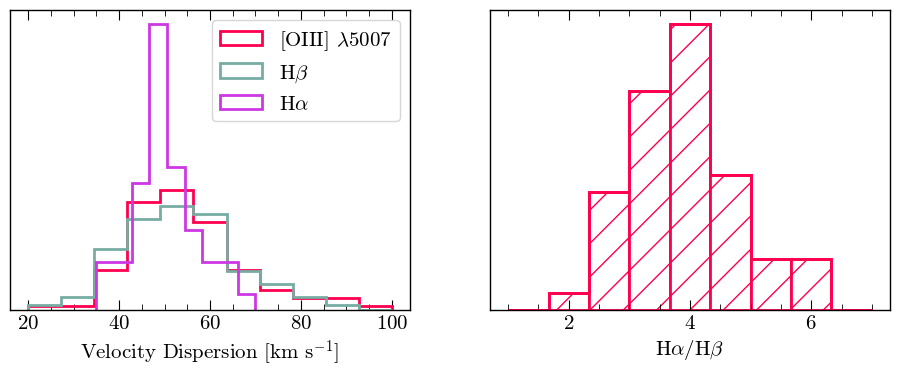

In [80]:
fig, ax = pf.create_plot()
lines = ['oiii5007', 'hbeta', 'halpha']
colors= ['#ff004f', '#77aca2', "#cd37e4"]
bins = 2*[np.linspace(20,100,12)]+[np.linspace(35,70,10)]
for i,l in enumerate(lines):
    ax.hist(tab[l+'_vel_disp'], bins=bins[i], histtype='step', lw=2, label=lambda_keys.get(l), density=True, color=colors[i])
ax.legend()
ax.set_yticks([])
ax.set_xlabel('Velocity Dispersion [km s$^{-1}$]')

ax2 = fig.add_axes((1.2,0,1,1))

hahb = tab['halpha_flux']/tab['hbeta_flux']
mask = np.isfinite(hahb)&(hahb>0)
ax2.hist(hahb[mask],bins=np.linspace(1,7,10), histtype='step', lw=2, density=True, color='#ff004f')
ax2.hist(hahb[mask],bins=np.linspace(1,7,10), lw=2, density=True, edgecolor='#ff004f', hatch="/", facecolor='white')

ax2.set_yticks([])
ax2.set_xlabel(r'H$\alpha$/H$\beta$')

pf.fix_plot([ax,ax2])

True

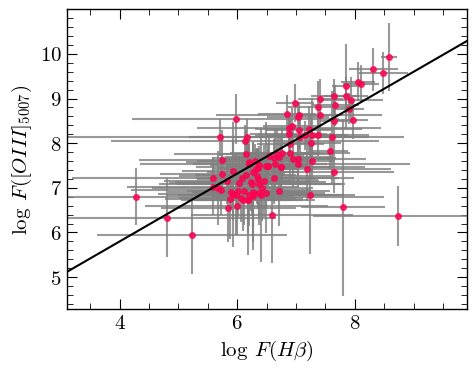

In [64]:
fig, ax = pf.create_plot()

xlims = (3.3,9.7)
xlol = np.log(tab['hbeta_flux'])<xlims[0]
xup = np.log(tab['hbeta_flux'])>xlims[1]

ax.errorbar(np.log(tab['hbeta_flux']),np.log(tab['oiii5007_flux']), 
            fmt='o', color='#ff004f', ms=4,
            xerr= np.abs(((tab['hbeta_flux_err'])/(tab['hbeta_flux']))*np.log(tab['hbeta_flux'])),
            yerr = np.abs((tab['oiii5007_flux_err']/tab['oiii5007_flux'])*np.log(tab['oiii5007_flux'])),
            ecolor='gray', alpha=0.8, xlolims=xlol, xuplims=xup)

ax.set_ylabel(r'$\log\;F([OIII]_{5007})$')
ax.set_xlabel(r'$\log\;F(H\beta)$')

ax.set_xlim(3.1,9.9)

xvals = np.log(tab['hbeta_flux'])
yvals = np.log(tab['oiii5007_flux'])
yerr = np.abs((tab['oiii5007_flux_err']/tab['oiii5007_flux'])*np.log(tab['oiii5007_flux']))

mask = (np.isfinite(xvals))&(np.isfinite(yvals))
popt, cov = curve_fit(linear,xvals[mask], yvals[mask], p0=2*[0], sigma=yerr[mask])
grid = np.linspace(3,10,100)
ax.plot(grid, linear(grid,*popt), color='k',zorder=10)

pf.fix_plot([ax])


In [57]:
yvals[mask]

7.319873963344411
8.521437535069564
7.493489578953355
8.050028439310628
7.273802903477329
8.288315070600383
7.698702865048631
7.504114290864653
7.821407137907455
6.905310605801426
-inf


True

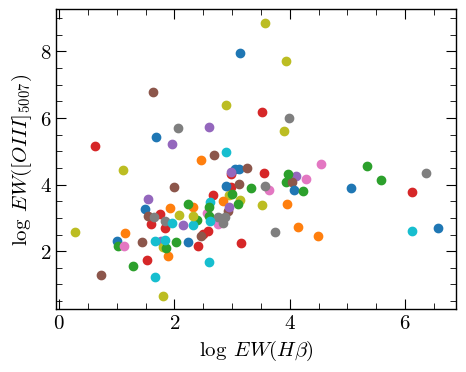

In [7]:
fig, ax = pf.create_plot()

minitab = tab.group_by('name')
for g in minitab.groups:
    ax.scatter(np.log(g['hbeta_ew']),np.log(g['oiii5007_ew']))

ax.set_ylabel(r'$\log\;EW([OIII]_{5007})$')
ax.set_xlabel(r'$\log\;EW(H\beta)$')

pf.fix_plot([ax])

True

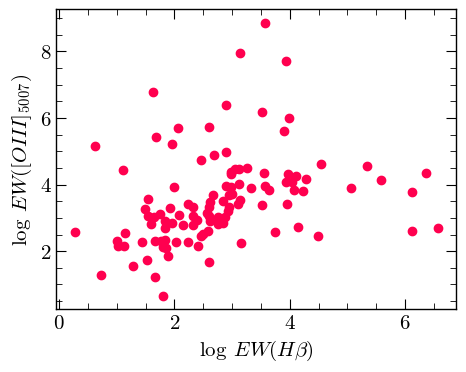

In [8]:
fig, ax = pf.create_plot()
ax.scatter(np.log(tab['hbeta_ew']),np.log(tab['oiii5007_ew']), color='#ff004f')
ax.set_ylabel(r'$\log\;EW([OIII]_{5007})$')
ax.set_xlabel(r'$\log\;EW(H\beta)$')
pf.fix_plot([ax])

True

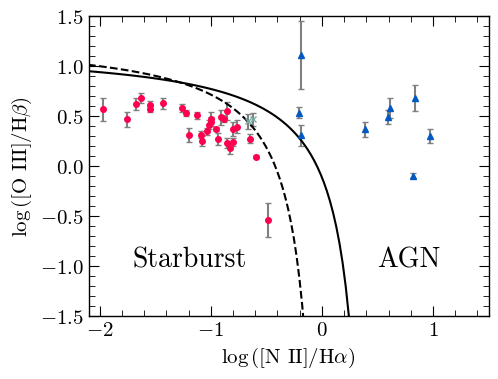

In [29]:
fig, ax = pf.create_plot()
ax.set_xlabel(r'$\log$([N II]/H$\alpha$)')
ax.set_ylabel(r'$\log$([O III]/H$\beta$)')

xvals = np.log10(tab['nii6583_flux']/tab['halpha_flux'])
yvals = np.log10(tab['oiii5007_flux']/tab['hbeta_flux'])

xerr = np.abs(xvals*np.sqrt( (tab['nii6583_flux_err']/tab['nii6583_flux'])**2 + (tab['halpha_flux_err']/tab['halpha_flux'])**2 ))
yerr = np.abs(yvals*np.sqrt( (tab['oiii5007_flux_err']/tab['oiii5007_flux'])**2 + (tab['hbeta_flux_err']/tab['hbeta_flux'])**2 ))

classf = lr.classify_bpt(xvals,yvals)
markers = ['o','x','^']
colors = ['#ff004f', "#77aca2", "#0359c3"]


for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)
    ax.errorbar(xvals[mask],yvals[mask], fmt=markers[i], yerr=yerr[mask], color=colors[i], ms=4, ecolor='gray', capsize=2)
ax.set_xlim(-2.1,1.5)
ax.set_ylim(-1.5,1.5)

grid = np.linspace(-2.5,0, 100)
grid2 = np.linspace(-2.5,.3, 100)

ax.plot(grid,lr.kauffmann03(grid),color='k', ls='--')
ax.plot(grid2,lr.kewley01(grid2),color='k')

ax.text(-1.7,-1,'Starburst', fontsize=20)
ax.text(0.5,-1,'AGN', fontsize=20)

pf.fix_plot([ax])

True

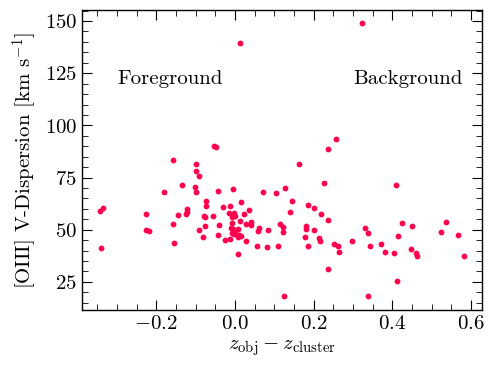

In [53]:
fix, ax = pf.create_plot()

ax.scatter((tab['z']-tab['zcluster']),tab['oiii5007_vel_disp'], color='#ff004f', s=10)
ax.text(-.3,120,'Foreground', fontsize=15)
ax.text(.3,120,'Background', fontsize=15)


ax.set_xlabel(r'$z_{\mathrm{obj}}-z_{\mathrm{cluster}}$')
ax.set_ylabel(r'[OIII] V-Dispersion [km s$^{-1}$]')
pf.fix_plot([ax])

In [ ]:
fig, ax = 